In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# CEBU - Labor Supply 2024

*Note:* For the calculation of the 

### Loading Data and Qualifications

In [6]:
# Load the Excel file
file_path = "data/TESDA 2024 EGAC.xlsx"  # change to your actual path
xls = pd.ExcelFile(file_path)

# Load a specific sheet
df_eg = pd.read_excel(xls, sheet_name='EG 2024')
df_ac = pd.read_excel(xls, sheet_name='AC 2024', header = 1)

In [4]:
unique_quals = df_eg['Qualification'].dropna().unique()
#print(unique_quals)

In [7]:
NC_list = [
    # TOURISM
    "Barista NC II",
    "Bartending NC II",
    "Bread and Pastry Production NC II",
    "Cookery NC II",
    "Events Management Services NC III",
    "Food and Beverage Services NC II",
    "Food and Beverage Services NC III",
    "Food and Beverage Services NC IV",
    "Front Office Services NC II",
    "Housekeeping NC II",
    "Housekeeping NC III",
    "Housekeeping NC IV",
    "Local Guiding Services NC II",
    "Tour Guiding Services NC II",
    "Tourism Promotion Services NC II",
    "Tour Packaging (FIT Ad Hoc Domestic) Services NC II",
    "Travel Services NC II",

    # CONSTRUCTION
    "Carpentry NC II",
    "Carpentry NC III",
    "Construction Painting NC II",
    "Electrical Installation and Maintenance NC II",
    "Electrical Installation and Maintenance NC III",
    "Electrical Installation and Maintenance NC IV",
    "Heavy Equipment Operation (Backhoe Loader) NC II",
    "Heavy Equipment Operation (Bulldozer) NC II",
    "Heavy Equipment Operation (Concrete Pump) NC II",
    "Heavy Equipment Operation (Crawler Crane) NC II",
    "Heavy Equipment Operation (Crawler Crane) NC III",
    "Heavy Equipment Operation (Gantry Crane) NC II",
    "Heavy Equipment Operation (Motor Grader) NC II",
    "Heavy Equipment Operation (Overhead and Gantry Crane) NC III",
    "Heavy Equipment Operation (Road Roller) NC II",
    "Heavy Equipment Operation (Rough Terrain Crane) NC II",
    "Heavy Equipment Operation (Rough Terrain Crane) NC III",
    "Heavy Equipment Operation (Tower Crane) NC II",
    "Heavy Equipment Operation (Tower Crane) NC III",
    "Heavy Equipment Operation (Transit Mixer) NC II",
    "Heavy Equipment Operation (Truck Mounted Crane) NC II",
    "Heavy Equipment Operation (Truck Mounted Crane) NC III",
    "Heavy Equipment Operation (Wheel Loader) NC II",
    "Heavy Equipment Servicing (Mechanical) NC II",
    "Masonry NC I",
    "Masonry NC II",
    "Masonry NC III",
    "Plumbing NC I",
    "Plumbing NC II",
    "Plumbing NC III",
    "PV Systems Installation NC II",
    "PV Systems Servicing NC III",
    "Reinforcing Steel Works NC II",
    "Rigging NC I",
    "Scaffolding Works (Supported Type Scaffold) NC II",
    "System Formworks Installation NC II",
    "Tile Setting NC II",

    # MANUFACTURING
    "Automotive Body Repairing NC II",
    "Automotive Painting NC II",
    "CNC Lathe Machine Operation NC II",
    "CNC Milling Machine Operation NC II",
    "Electronic Products Assembly and Servicing NC II",
    "Flux-Cored Arc Welding (FCAW) NC II",
    "Gas Metal Arc Welding (GMAW) NC I",
    "Gas Metal Arc Welding (GMAW) NC II",
    "Gas Metal Arc Welding (GMAW) NC III",
    "Gas Tungsten Arc Welding (GTAW) NC II",
    "Instrumentation and Control Servicing NC II",
    "Instrumentation and Control Servicing NC III",
    "Machining NC I",
    "Machining NC II",
    "Mechatronics Servicing NC II",
    "Mechatronics Servicing NC III",
    "Mechatronics Servicing NC IV",
    "Pipefitting (Metallic) NC II",
    "Shielded Metal Arc Welding (SMAW) NC I",
    "Shielded Metal Arc Welding (SMAW) NC II",
    "Shielded Metal Arc Welding (SMAW) NC III",
    "Shielded Metal Arc Welding (SMAW) NC IV",
    "Technical Drafting NC II"
]


## Total Enrolled (E)

In [7]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_eg[
    (df_eg["Region Name"] == "Region VII - Central Visayas") &
    (df_eg["Province Name"] == "Cebu") &
    (df_eg["Qualification"].isin(NC_list))
]

total_enrolled = region_vii_cebu_tourism["Enrolled"].sum()
population_percentage = total_enrolled

print("Total Enrolled (Tourism & Hospitality, Region VII - Central Visayas):", total_enrolled)

Total Enrolled (Tourism & Hospitality, Region VII - Central Visayas): 17930


## Total Graduated (G)

In [8]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_eg[
    (df_eg["Region Name"] == "Region VII - Central Visayas") &
    (df_eg["Province Name"] == "Cebu") &
    (df_eg["Qualification"].isin(NC_list))
]

total_graduated = region_vii_cebu_tourism["Graduates"].sum()

print("Total Graduates (Tourism & Hospitality, Region VII - Central Visayas):", total_graduated)

Total Graduates (Tourism & Hospitality, Region VII - Central Visayas): 18182


In [12]:
overall = region_vii_cebu_tourism.groupby('Qualification')['Graduates'].sum().sum()
region_vii_cebu_tourism.groupby('Qualification')['Graduates'].sum().sort_values(ascending=False) / overall

Qualification
Bread and Pastry Production NC II                   0.305137
Shielded Metal Arc Welding (SMAW) NC II             0.143714
Cookery NC II                                       0.132659
Housekeeping NC II                                  0.082609
Electrical Installation and Maintenance NC II       0.070234
Events Management Services NC III                   0.054779
Shielded Metal Arc Welding (SMAW) NC I              0.041360
Heavy Equipment Operation (Motor Grader) NC II      0.024695
Heavy Equipment Operation (Bulldozer) NC II         0.023100
Food and Beverage Services NC II                    0.022550
Electronic Products Assembly and Servicing NC II    0.018755
Tile Setting NC II                                  0.012100
Gas Metal Arc Welding (GMAW) NC II                  0.008140
Carpentry NC II                                     0.008085
Plumbing NC II                                      0.006490
Masonry NC II                                       0.006160
Machining 

### Bar Chart for Tourism Graduates

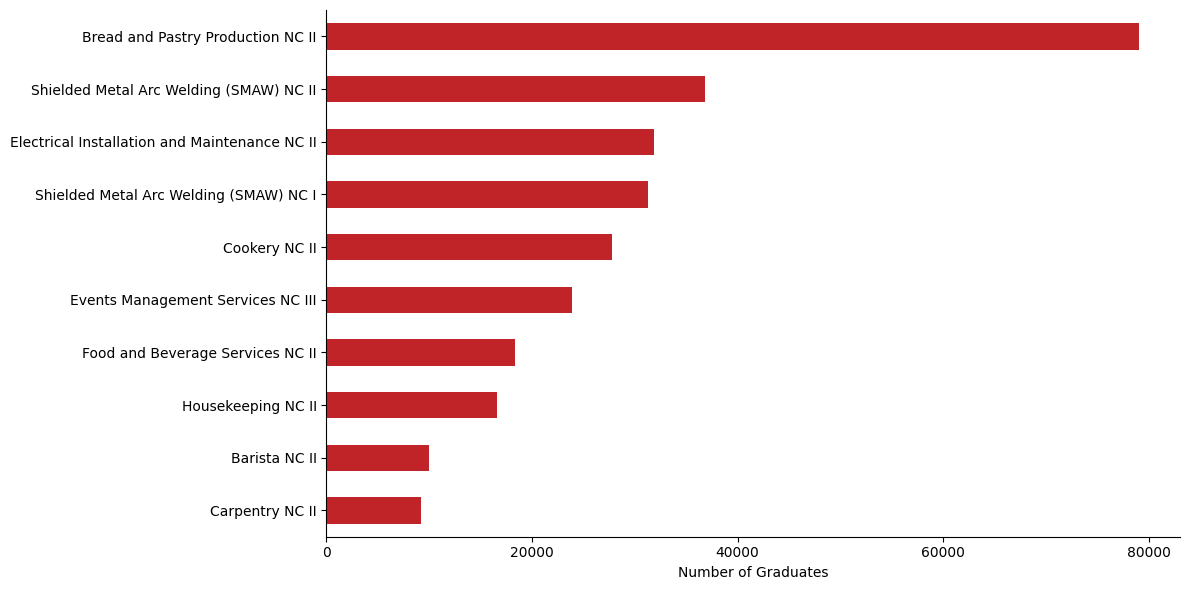

In [21]:
# Filter rows with qualifications in the NC list
filtered_df = df_eg[df_eg['Qualification'].isin(NC_list)]

# Group by qualification and sum graduates
graduates_by_nc = (
    filtered_df.groupby('Qualification')['Graduates']
    .sum()
    .sort_values(ascending=False)
)

# Keep only the top 10
top10_graduates = graduates_by_nc.head(10)

# Create horizontal bar chart
plt.figure(figsize=(12, 6))
ax = top10_graduates.plot(kind='barh', color='#c12428ff')  # use custom color

# Style adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("")  # remove y-axis label
plt.xlabel("Number of Graduates")
plt.gca().invert_yaxis()  # highest value on top

# Limit x-axis ticks to 5
ax.xaxis.set_major_locator(plt.MaxNLocator(5))

plt.tight_layout()
plt.show()


### Loading Data and Qualifications

In [136]:
unique_quals = df_ac['Qualification'].dropna().unique()
#print(unique_quals)

## Total Assessed (A)

In [137]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_ac[
    (df_ac["Region"] == "Region VII - Central Visayas") &
    (df_ac["Province"] == "Cebu") &
    (df_ac["Qualification"].isin(NC_list))
]

total_assessed = region_vii_cebu_tourism["Assessed"].sum()

print("Total Assessed (Tourism & Hospitality, Region VII - Central Visayas):", total_assessed)

Total Assessed (Tourism & Hospitality, Region VII - Central Visayas): 36002


In [138]:
region_vii_cebu_tourism

,Assessment Center,Class Name,Region,Province,City Name,Address,Center Manager,Phone,e mail,Qualification,Numberof Accredited Ass Qual,Assessed,Certified
14146,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,NaN,Region VII - Central Visayas,Cebu,Asturias,"Sitio Lamac, New Bago, Asturias",Michail . Chang,(032) 328-9150 / (032) 328-9153,3aprimeac7@gmail.com,Bread and Pastry Production NC II,1,20,20
14147,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,NaN,Region VII - Central Visayas,Cebu,Asturias,"Sitio Lamac, New Bago, Asturias",Michail . Chang,(032) 328-9150 / (032) 328-9153,3aprimeac7@gmail.com,Bread and Pastry Production NC II,1,22,22
14148,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,NaN,Region VII - Central Visayas,Cebu,Asturias,"Sitio Lamac, New Bago, Asturias",Michail . Chang,(032) 328-9150 / (032) 328-9153,3aprimeac7@gmail.com,Bread and Pastry Production NC II,1,10,10
14149,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,NaN,Region VII - Central Visayas,Cebu,Asturias,"Sitio Lamac, New Bago, Asturias",Michail . Chang,(032) 328-9150 / (032) 328-9153,3aprimeac7@gmail.com,Bread and Pastry Production NC II,1,29,29
14150,3A PRIME HOSPITALITY TRAINING AND ASSESSMENT C...,NaN,Region VII - Central Visayas,Cebu,Asturias,"Sitio Lamac, New Bago, Asturias",Michail . Chang,(032) 328-9150 / (032) 328-9153,3aprimeac7@gmail.com,Bread and Pastry Production NC II,1,144,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15644,VISAYAN INSTITUTE OF TECHNOLOGY AGRIBUSINESS A...,NaN,Region VII - Central Visayas,Cebu,Samboan,"Poblacion, Samboan, Cebu",Ada Marie A. Capistrano,0995-842-7877 / 0907-361-9529,vitalskillsinc@gmail.com,Housekeeping NC II,1,30,30
15645,VISAYAN INSTITUTE OF TECHNOLOGY AGRIBUSINESS A...,NaN,Region VII - Central Visayas,Cebu,Samboan,"Poblacion, Samboan, Cebu",Ada Marie A. Capistrano,0995-842-7877 / 0907-361-9529,vitalskillsinc@gmail.com,Housekeeping NC II,1,20,20
15646,"ZEO AND ZOE TRAINING AND ASSESSMENT CENTER, INC.",NaN,Region VII - Central Visayas,Cebu,Liloan,"Tiwasan Purok Alugbati Catarman, Liloan, Cebu",Ma. Katrine Y. Caballe,(032) 407-6260 0926-475-9980,zeozoecebu@gmail.com,Shielded Metal Arc Welding (SMAW) NC II,1,23,23
15647,"ZEO AND ZOE TRAINING AND ASSESSMENT CENTER, INC.",NaN,Region VII - Central Visayas,Cebu,Liloan,"Tiwasan Purok Alugbati Catarman, Liloan, Cebu",Ma. Katrine Y. Caballe,(032) 407-6260 0926-475-9980,zeozoecebu@gmail.com,Shielded Metal Arc Welding (SMAW) NC II,1,5,5


## Total Certified (C)

In [139]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df_ac[
    (df_ac["Region"] == "Region VII - Central Visayas") &
    (df_ac["Province"] == "Cebu") &
    (df_ac["Qualification"].isin(NC_list))
]

total_certified = region_vii_cebu_tourism["Certified"].sum()

print("Total Certified (Tourism & Hospitality, Region VII - Central Visayas):", total_certified)

Total Certified (Tourism & Hospitality, Region VII - Central Visayas): 35318


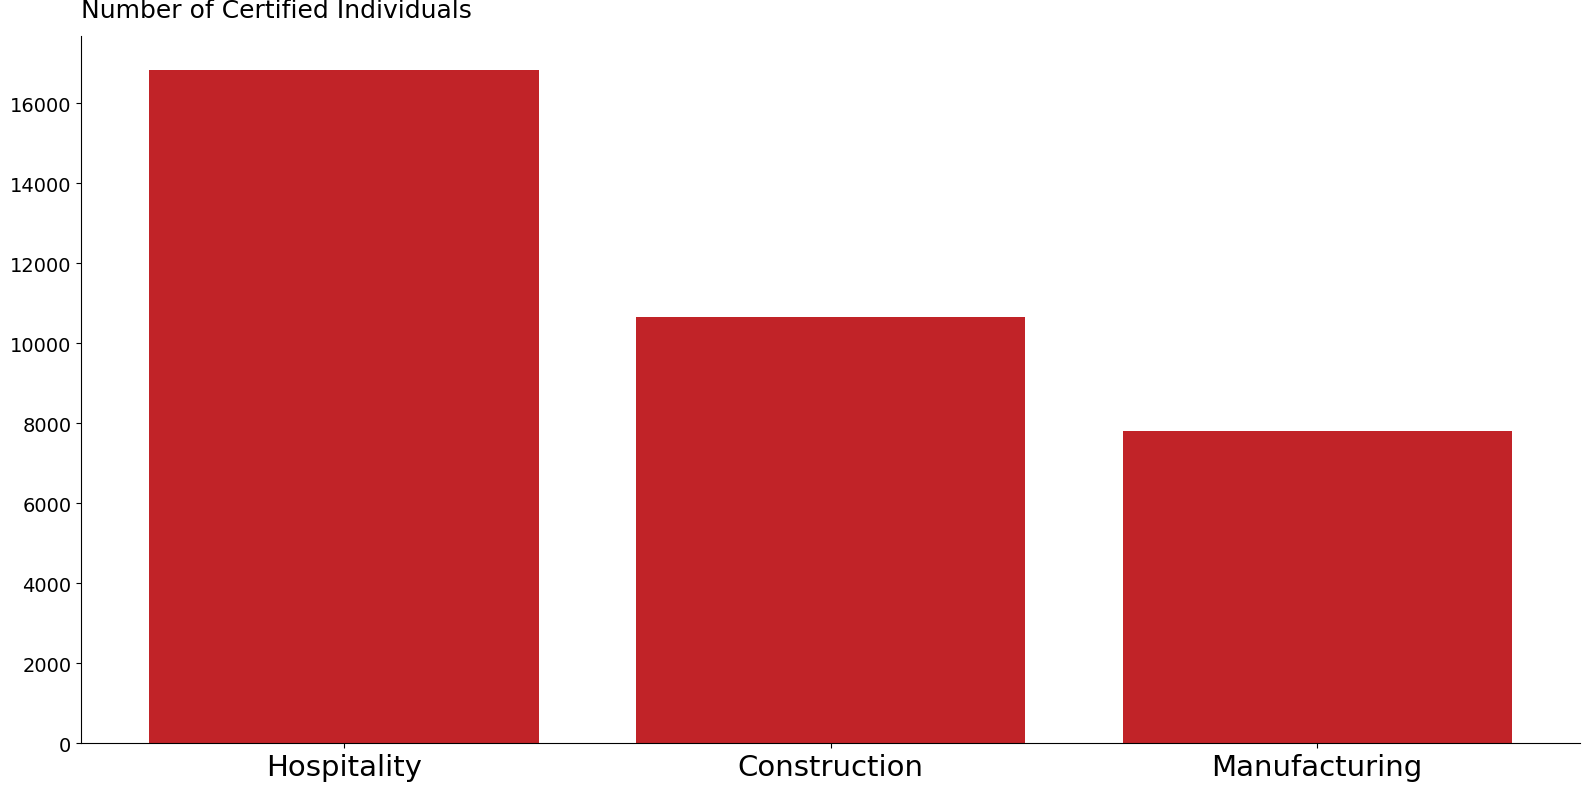

In [125]:
# --- sector mapping ---
tourism_list = NC_list[:17]
construction_list = NC_list[17:17+42]
manufacturing_list = NC_list[17+42:]

def get_sector(qualification):
    if qualification in tourism_list:
        return "Hospitality"
    elif qualification in construction_list:
        return "Construction"
    elif qualification in manufacturing_list:
        return "Manufacturing"
    else:
        return "Other"

# --- apply mapping ---
region_vii_cebu_tourism.loc[:, 'Sector'] = region_vii_cebu_tourism['Qualification'].apply(get_sector)

# --- group and sum ---
sector_summary = (
    region_vii_cebu_tourism.groupby('Sector')['Certified']
    .sum()
    .reset_index()
    .sort_values(by='Certified', ascending=False)   # sort highest → lowest
)

# --- bar chart ---
plt.figure(figsize=(16, 8))
plt.bar(sector_summary['Sector'], sector_summary['Certified'], color='#c12328')

# labels and style
plt.ylabel('Number of Certified Individuals', rotation=0, ha='left', fontsize=18, labelpad=60)
plt.gca().yaxis.set_label_coords(0, 1.02)
plt.xticks(rotation=0, fontsize=21)
plt.yticks(fontsize=14)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



In [131]:
region_vii_cebu_tourism.groupby('Sector')['Enrolled']


# CEBU - Labor Supply 2025

### Loading Data and Qualifications

loading the file

In [67]:
file_path = "data/EG 2025.csv"
df = pd.read_csv(file_path)

entries under column "Region Name"

In [68]:
# Get unique region names
unique_regions = df["Region Name"].dropna().unique()

# Print or save them
print(unique_regions)

['Region I - Ilocos' 'National Capital Region (NCR)'
 'Region X - Northern Mindanao' 'Region VII - Central Visayas'
 'Cordillera Administrative Region (CAR)' 'Region V - Bicol'
 'Region VI - Western Visayas' 'Region VIII - Eastern Visayas'
 'Region III - Central Luzon' 'Region II - Cagayan Valley'
 'Region IVA - CALABARZON' 'Region IVB - MIMAROPA'
 'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)'
 'Region XI - Davao' 'Region IX - Zamboanga Peninsula'
 'Region XII - SOCCSKSARGEN' 'Region XIII - CARAGA'
 'Autonomous Region in Muslim Mindanao (ARMM)']


In [69]:
# Get unique qualifications
unique_qualifications = df["Qualification"].dropna().unique()

# Print the results
print(unique_qualifications)

['Caregiving NC II' 'Computer Systems Servicing NC II'
 'Automotive Servicing NC I' 'Barista NC II'
 'Bread and Pastry Production NC II' 'Cookery NC II'
 'Electrical Installation and Maintenance NC II'
 'Food and Beverage Services NC II'
 'Shielded Metal Arc Welding (SMAW) NC II'
 "Ships' Catering (Ships' Cooks) NC III" "Ship's Catering Services NC I"
 'Heavy Equipment Operation (Backhoe Loader) NC II' 'Bookkeeping NC III'
 'Hilot (Wellness Massage) NC II' 'Tile Setting NC II'
 'Organic Agriculture Production NC II' 'Driving NC II'
 'Rice Machinery Operations NC II' 'Dressmaking NC II'
 'Electronic Products Assembly and Servicing NC II'
 'Shielded Metal Arc Welding (SMAW) NC I'
 'Events Management Services NC III' 'Caregiving (Elderly) NC II'
 'Trainers Methodology Level I' 'Domestic Work NC II'
 'Heavy Equipment Operation (Motor Grader) NC II' 'Housekeeping NC II'
 'Bartending NC II' 'Contact Center Services NC II'
 'Electrical Installation and Maintenance NC III'
 'Mechatronics Servi

In [ ]:
tourism_hospitality_list = [
    # Hospitality & Tourism Operations
    "Front Office Services NC II",
    "Tourism Promotion Services NC II",
    "Tour Guiding Services NC II",
    "Events Management Services NC III",
    "Contact Center Services NC II",
    "Housekeeping NC II",
    "Housekeeping NC III",
    "Security Services NC II",

    # Restaurant & Food Service Operations
    "Food and Beverage Services NC II",
    "Food and Beverage Services NC III",
    "Bartending NC II",
    "Barista NC II",
    "Cookery NC II",
    "Bread and Pastry Production NC II",
    "Commercial Cooking NC III",
    "Commercial Cooking NC IV",

    # Culinary Arts & Kitchen Management
    "Food Processing NC II",

    # Travel & Tourism Technology
    "Tour Guiding Services NC II",
    "Tourism Promotion Services NC II",
    "Front Office Services NC II",

    # Related Support Roles in Hospitality
    "Bookkeeping NC III",
    "Customer Services NC II",
    "Medical Transcription NC II",
    "Hilot (Wellness Massage) NC II"
]


## Total Enrolled (E)

In [71]:
# Filter rows for Region VII - Central Visayas and tourism/hospitality qualifications
region_vii_cebu_tourism = df[
    (df["Region Name"] == "Region VII - Central Visayas") &
    (df["Province Name"] == "Cebu") &
    (df["Qualification"].isin(tourism_hospitality_list))
]

# Calculate total enrolled
total_enrolled = region_vii_cebu_tourism["Enrolled"].sum()

print("Total Enrolled (Tourism & Hospitality, Region VII - Central Visayas):", total_enrolled)

Total Enrolled (Tourism & Hospitality, Region VII - Central Visayas): 3416


## Total Graduated (G)

In [72]:
# Calculate total graduates
total_graduates = region_vii_cebu_tourism["Graduates"].sum()

print("Total Graduates (Tourism & Hospitality, Region VII - Central Visayas):", total_graduates)

Total Graduates (Tourism & Hospitality, Region VII - Central Visayas): 3015


### Loading Data and Qualifications

Getting entries under column "Qualification"

In [73]:
file_path2 = "data/AG 2025.csv"
df2 = pd.read_csv(file_path2, header=1)

In [74]:
df2.columns = df2.columns.str.strip()
df2["Qualification"] = df2["Qualification"].astype(str).str.strip()
unique_qualifications = df["Qualification"].unique()

print(unique_qualifications)

['Caregiving NC II' 'Computer Systems Servicing NC II'
 'Automotive Servicing NC I' 'Barista NC II'
 'Bread and Pastry Production NC II' 'Cookery NC II'
 'Electrical Installation and Maintenance NC II'
 'Food and Beverage Services NC II'
 'Shielded Metal Arc Welding (SMAW) NC II'
 "Ships' Catering (Ships' Cooks) NC III" "Ship's Catering Services NC I"
 'Heavy Equipment Operation (Backhoe Loader) NC II' 'Bookkeeping NC III'
 'Hilot (Wellness Massage) NC II' 'Tile Setting NC II'
 'Organic Agriculture Production NC II' 'Driving NC II'
 'Rice Machinery Operations NC II' 'Dressmaking NC II'
 'Electronic Products Assembly and Servicing NC II'
 'Shielded Metal Arc Welding (SMAW) NC I'
 'Events Management Services NC III' 'Caregiving (Elderly) NC II'
 'Trainers Methodology Level I' 'Domestic Work NC II'
 'Heavy Equipment Operation (Motor Grader) NC II' 'Housekeeping NC II'
 'Bartending NC II' 'Contact Center Services NC II'
 'Electrical Installation and Maintenance NC III'
 'Mechatronics Servi

In [75]:
# Define tourism qualifications
tourism_list = [
    "Tour Guiding Services NC II",
    "Tourism Promotion Services NC II",
    "Front Office Services NC II",
    "Food and Beverage Services NC II",
    "Bartending NC II",
    "Housekeeping NC II",
    "Barista NC II",
    "Cookery NC II",
    "Bread and Pastry Production NC II",
    "Commercial Cooking NC III",
    "Commercial Cooking NC IV",
    "Events Management Services NC III",
    "Travel Services NC II"
]

## Total Assessed (A)

In [76]:
# Clean up spaces and hidden characters
df2.columns = df2.columns.str.strip().str.replace('\ufeff', '', regex=True)
df2["Region"] = df2["Region"].astype(str).str.strip()
df2["Qualification"] = df2["Qualification"].astype(str).str.strip()

region_vii_cebu_tourism = df2[
    (df2["Region"] == "Region VII - Central Visayas") &
    (df2["Province"] == "Cebu") &
    (df2["Qualification"].isin(tourism_list))
]

# Calculate total assessed
total_assessed = region_vii_cebu_tourism["Assessed"].sum()
print("Total Assessed (Tourism, Region VII - Central Visayas):", total_assessed)


Total Assessed (Tourism, Region VII - Central Visayas): 5140.0


## Total Certified (C)

In [77]:
# Calculate total certified
total_certified = region_vii_cebu_tourism["Certified"].sum()

print("Total Certified (Tourism, Region VII - Central Visayas):", total_certified)

Total Certified (Tourism, Region VII - Central Visayas): 5057.0
